In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import re
from itertools import product
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statannotations.Annotator import Annotator

# Color Palette

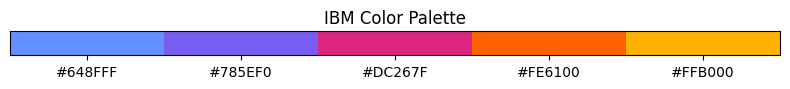

In [3]:
ibm_colors = [
    "#648FFF",
    "#785EF0",
    "#DC267F",
    "#FE6100",
    "#FFB000",
]

rgb_colors = [mcolors.to_rgba(c) for c in ibm_colors]

fig, ax = plt.subplots(figsize=(8, 1))

for i, color in enumerate(ibm_colors):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=color))

ax.set_xlim(0, len(ibm_colors))
ax.set_ylim(0, 1)

ax.set_xticks(np.arange(len(ibm_colors)) + 0.5)
ax.set_xticklabels(ibm_colors, ha="center")

ax.set_yticks([])

ax.set_title("IBM Color Palette")

plt.tight_layout()
plt.show()

mycolors = [rgb_colors[0], rgb_colors[2], rgb_colors[4]]

# Something something

In [4]:
root_path = Path("../data/target_validation").resolve().absolute()

df_old = (
    pd.read_csv(root_path / "ADPKD-TargetValidationScreen_Batch3791_and_Batch3753.csv")
    .assign(QC_problems=lambda x: x["QC_problems"].fillna("-"))
    .query("QC_problems == '-'")
)

# Actual plotting

In [5]:
mycpds_treatment = [
    "Finerenone",
    "Esaxerenone",
]


def plot_single_plate(compounds, plate_number, double_treat_cpd, stimulant_dose, savefig=True):
    subset = df_old.query(f"plate_id == {plate_number}")
    other_dose_idxs = subset[
        (subset["Stimulant dose"] != stimulant_dose)
        & (subset["treatment_type"].isin(["stim_only", "treatment"]))
    ].index.tolist()
    subset = subset.drop(index=other_dose_idxs)

    idxs = subset.loc[
        (subset["treatment_type"].isin(["solvent_ctrl", "stim_only"])) & (subset["Stimulant"] == "FSK")
    ].index.tolist()
    subset.loc[idxs, "Treatment"] = subset.loc[idxs, "Stimulant"]
    subset.loc[idxs, "Treatment concentration"] = stimulant_dose
    subset.loc[idxs, "Treatment unit"] = "uM"

    subset = subset.assign(
        treat_string=lambda x: x["Treatment"]
        + x["Treatment concentration"].astype(str)
        + " "
        + x["Treatment 2"]
        + x["Treatment 2 concentration"].astype(str)
    ).assign(
        treat_string=lambda x: (
            x["treat_string"]
            .str.replace("DMSO0.1 DMSO0.1", "DMSO 0.1%")
            .str.replace(f"FSK{stimulant_dose}", f"FSK {stimulant_dose}µM")
            .str.replace("DMSO0.1", "")
            .str.replace("0.001", " 0.001µM ")
            .str.replace("1.0", " 1µM ")
            .str.replace("0.1 ", " 0.1µM ")
            .str.replace(f"{double_treat_cpd}0.1", f"{double_treat_cpd} 0.1µM")
            .str.strip()
        ).apply(
            lambda s: " ".join(s.split())  # remove double spaces
        )
    )

    single_treatment = subset[
        (subset["Treatment 2"] == f"{double_treat_cpd}") & (subset["Treatment"] == "DMSO")
    ].copy()
    single_treatment["Treatment"] = f"{double_treat_cpd}"

    for cpd in compounds:
        subset_controls = pd.concat(
            [
                subset.query("treatment_type.isin(['solvent_ctrl'])"),
                subset.query("treatment_type.isin(['stim_only'])"),
                single_treatment.sort_values(["Treatment concentration", "Treatment 2 concentration"]),
            ],
            ignore_index=True,
        )
        subset_controls["Treatment 2"] = "Control"

        subset_cpd = subset.query(f"Treatment == '{cpd}'")
        subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
            lambda x: 0 if x == "DMSO" else 1
        )
        subset_cpd = subset_cpd.sort_values(
            ["Treatment 2 Sort Key", "Treatment 2 concentration", "Treatment concentration"]
        ).drop(columns=["Treatment 2 Sort Key"])

        fig, ax = plt.subplots(figsize=(6, 4))
        plot_data = pd.concat(
            [
                subset_controls,
                subset_cpd,
            ]
        )
        plot_data["Treatment 2"] = plot_data["Treatment 2"].apply(
            lambda x: f"+ FSK {stimulant_dose}µM" if x == "DMSO" else x
        )
        plot_data["Treatment 2"] = plot_data["Treatment 2"].apply(
            lambda x: (
                f"+ {x} + FSK {stimulant_dose}µM" if x not in ["Control", f"+ FSK {stimulant_dose}µM"] else x
            )
        )
        sns.boxplot(
            data=plot_data,
            x="treat_string",
            y="obj.Mean(area).um2.meas",
            # hue="Treatment 2",
        )

        labels = plot_data[["treat_string", "Treatment 2"]].drop_duplicates()["Treatment 2"]
        uniq_labels = labels.drop_duplicates().tolist()
        # uniq_colors = sns.color_palette("tab10", n_colors=3)
        uniq_colors = mycolors
        colors = [uniq_colors[0]] * 2 + [uniq_colors[1]] * 6 + [uniq_colors[2]] * 6

        legend_handles = [
            mpatches.Patch(facecolor=color, label=label, edgecolor="black", linewidth=0.5)
            for label, color in zip(uniq_labels, uniq_colors)
        ]

        bars = ax.patches
        for bar, color in zip(bars, colors):
            bar.set_facecolor(color)

        ax.legend(
            handles=legend_handles, bbox_to_anchor=(1.04, 0), loc="lower left", borderaxespad=0, frameon=False
        )

        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)
        # Prepare pairs for statistical annotation
        control_condition = f"FSK {stimulant_dose}µM"
        concentrations = ["0.001µM", "0.1µM", "1µM"]
        treatment_conditions = [f"{a} {b}" for a, b in product([cpd, double_treat_cpd], concentrations)]
        double_treat_comparisons = (
            # DTC (double treatment compound) v.s. PC (plate compound) + DTC
            [(f"{double_treat_cpd} 1µM", f"{cpd} {c} {double_treat_cpd} 1µM") for c in concentrations]
            + [(f"{double_treat_cpd} 0.1µM", f"{cpd} {c} {double_treat_cpd} 0.1µM") for c in concentrations]
            # compound alone v.s. double treatment
            + [(f"{cpd} 1µM", f"{cpd} 1µM {double_treat_cpd} {c}") for c in concentrations[1:]]
            + [(f"{cpd} 0.1µM", f"{cpd} 0.1µM {double_treat_cpd} {c}") for c in concentrations[1:]]
            + [(f"{cpd} 0.001µM", f"{cpd} 0.1µM {double_treat_cpd} {c}") for c in concentrations[1:]]
            # double treatment v.s. double treatment
            + [
                (f"{cpd} 1µM {double_treat_cpd} 1µM", f"{cpd} 1µM {double_treat_cpd} 0.1µM"),
                (f"{cpd} 0.1µM {double_treat_cpd} 1µM", f"{cpd} 0.1µM {double_treat_cpd} 0.1µM"),
                (f"{cpd} 0.001µM {double_treat_cpd} 1µM", f"{cpd} 0.1µM {double_treat_cpd} 0.1µM"),
            ]
        )
        pairs = [(control_condition, cond) for cond in treatment_conditions] + double_treat_comparisons
        # Add statistical annotations
        annotator = Annotator(ax, pairs, data=plot_data, x="treat_string", y="obj.Mean(area).um2.meas")
        annotator.configure(
            test="Mann-Whitney",
            text_format="star",
            loc="inside",
            hide_non_significant=True,
        )
        annotator.apply_and_annotate()

        ax.set_xlabel("")
        ax.set_ylabel(r"Mean-Aggregated Cyst Size ($\mu$m$^2$)")
        ax.set_title(f"Plate {plate_number} - {cpd}")

        ax.grid(axis="y", alpha=0.5)
        ax.set_axisbelow(True)

        if savefig:
            fig.savefig(
                f"imgs/older_plate{plate_number}_{cpd}_FSK{str(stimulant_dose).replace('.', '-')}_{double_treat_cpd}.png",
                dpi=300,
                bbox_inches="tight",
                transparent=True,
            )

        plt.show()

## NR3C2

/tmp/ipykernel_2992906/2818115405.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_2992906/2818115405.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. Aldosterone 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.930e-03 U_stat=1.000e+00
FSK 2.5µM vs. Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.465e-03 U_stat=4.400e+01
FSK 2.5µM vs. Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.465e-03 U_stat=4.400e+01
Finerenone 1µM Aldosterone 0.1µM vs. Finerenone 1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. Finerenone 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.758e-02 U_stat=4.000e+00
Finerenone 0.001µM vs. Finerenone 0.1µM Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. Finerenone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.198e-02 U_stat=2.000e+00
Finerenone 1µM vs.

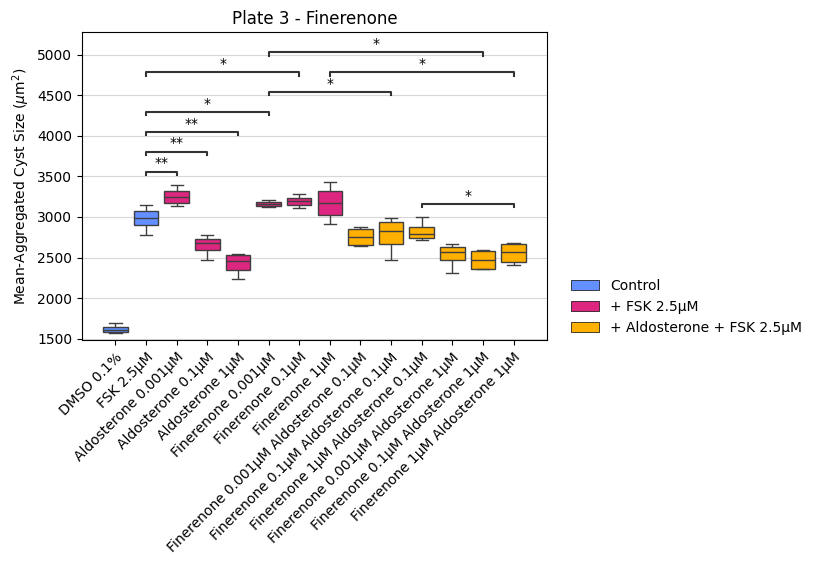

/tmp/ipykernel_2992906/2818115405.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_2992906/2818115405.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. Aldosterone 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.930e-03 U_stat=1.000e+00
FSK 2.5µM vs. Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.465e-03 U_stat=4.400e+01
FSK 2.5µM vs. Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.465e-03 U_stat=4.400e+01
Esaxerenone 1µM vs. Esaxerenone 1µM Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Esaxerenone 0.1µM Aldosterone 0.1µM vs. Esaxerenone 0.1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Esaxerenone 0.001µM vs. Esaxerenone 0.1µM Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. Esaxerenone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.465e-03 U_stat=

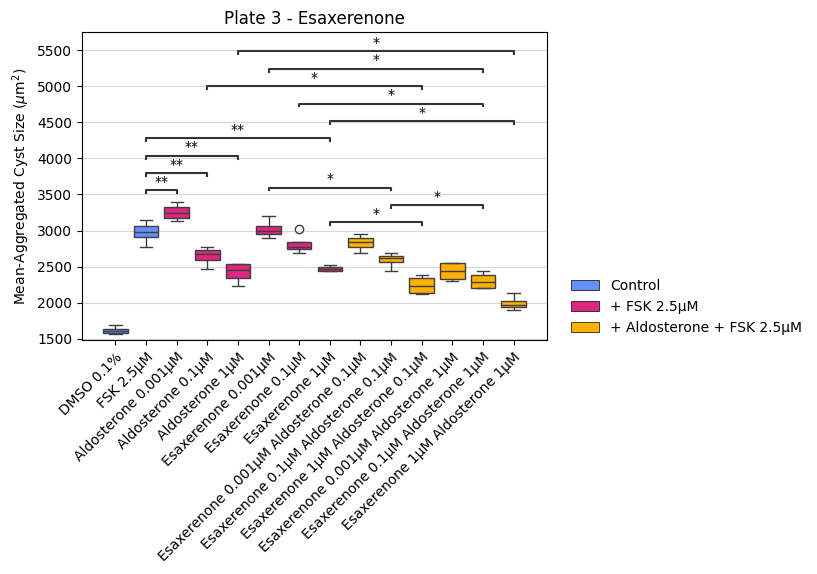

/tmp/ipykernel_2992906/2818115405.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_2992906/2818115405.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 0.79µM vs. Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.040e-03 U_stat=3.200e+01
FSK 0.79µM vs. Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.040e-03 U_stat=3.200e+01
Finerenone 1µM vs. Finerenone 1µM Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Finerenone 1µM Aldosterone 0.1µM vs. Finerenone 1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Finerenone 1µM vs. Finerenone 1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Finerenone 0.1µM vs. Finerenone 0.1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Finerenone 0.001µM vs. Finerenone 0.1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-

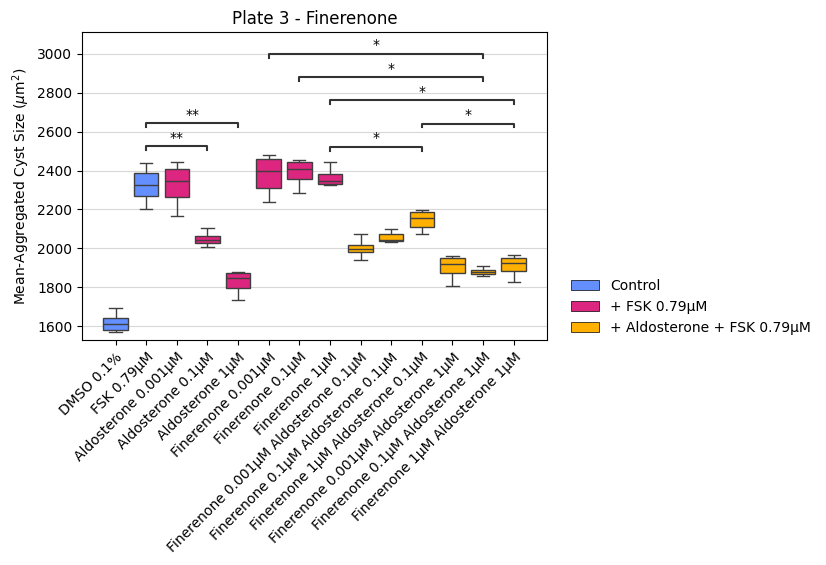

/tmp/ipykernel_2992906/2818115405.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_2992906/2818115405.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 0.79µM vs. Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.040e-03 U_stat=3.200e+01
FSK 0.79µM vs. Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.040e-03 U_stat=3.200e+01
Esaxerenone 1µM vs. Esaxerenone 1µM Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Esaxerenone 0.1µM vs. Esaxerenone 0.1µM Aldosterone 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Esaxerenone 1µM Aldosterone 0.1µM vs. Esaxerenone 1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Esaxerenone 0.1µM Aldosterone 0.1µM vs. Esaxerenone 0.1µM Aldosterone 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
Esaxerenone 0.001µM vs. Esaxerenone 0.1µM Aldosterone 0.

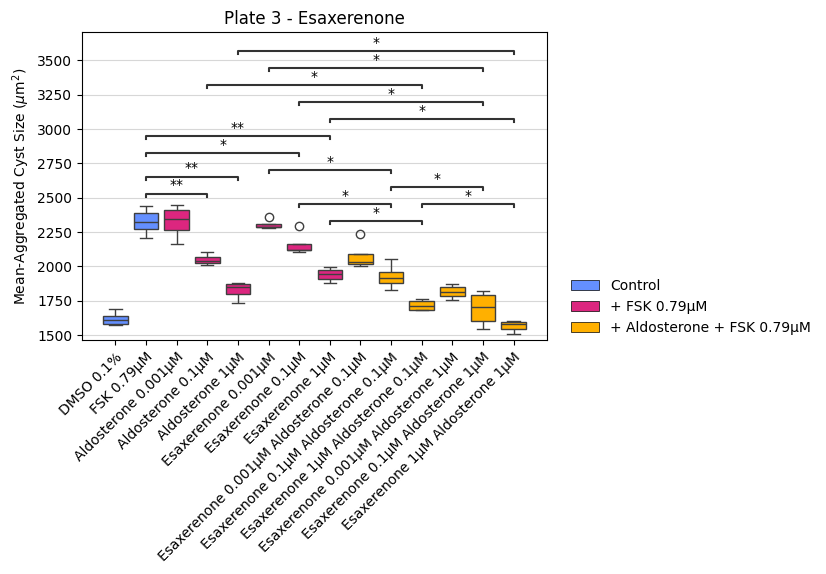

In [6]:
plot_single_plate(mycpds_treatment, 3, "Aldosterone", 2.5, savefig=False)
plot_single_plate(mycpds_treatment, 3, "Aldosterone", 0.79, savefig=False)

## ADORA1

/tmp/ipykernel_2992906/2818115405.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_2992906/2818115405.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.465e-03 U_stat=4.400e+01
FSK 2.5µM vs. DPCPX 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.465e-03 U_stat=0.000e+00
DPCPX 0.1µM vs. DPCPX 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
DPCPX 0.001µM vs. DPCPX 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
CPA 1µM vs. DPCPX 1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=0.000e+00


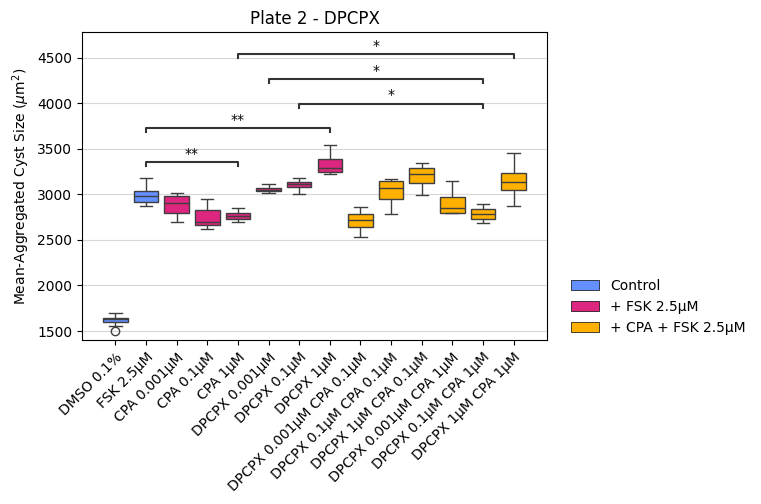

/tmp/ipykernel_2992906/2818115405.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_2992906/2818115405.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 2.5µM vs. CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.465e-03 U_stat=4.400e+01
Capadenoson 0.001µM vs. Capadenoson 0.1µM CPA 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 2.5µM vs. Capadenoson 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:1.465e-03 U_stat=4.400e+01
FSK 2.5µM vs. Capadenoson 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:5.495e-03 U_stat=3.300e+01
Capadenoson 0.1µM vs. Capadenoson 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=0.000e+00
Capadenoson 0.001µM vs. Capadenoson 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
CPA 1µM vs. Capadenoson 1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01


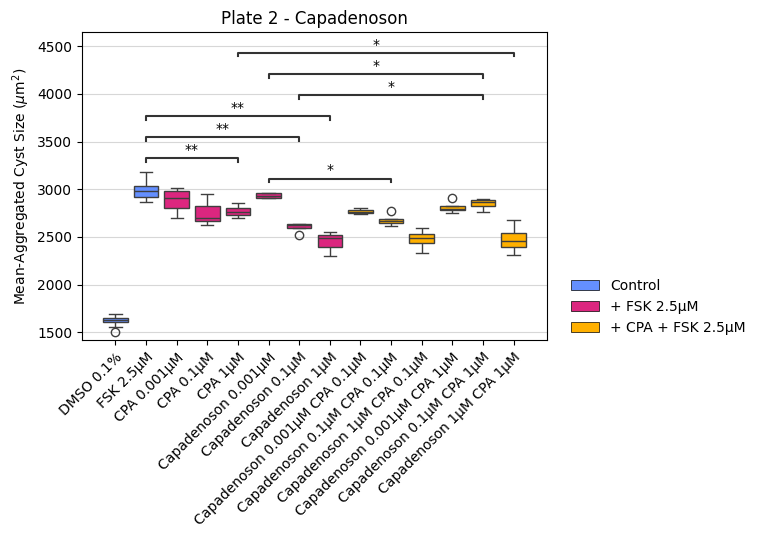

/tmp/ipykernel_2992906/2818115405.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_2992906/2818115405.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 0.79µM vs. CPA 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.848e-02 U_stat=2.200e+01
FSK 0.79µM vs. CPA 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.828e-02 U_stat=2.900e+01
DPCPX 0.1µM CPA 0.1µM vs. DPCPX 0.001µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 0.79µM vs. CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.828e-02 U_stat=2.900e+01
CPA 0.1µM vs. DPCPX 0.001µM CPA 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 0.79µM vs. DPCPX 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:8.081e-03 U_stat=1.000e+00
DPCPX 0.1µM vs. DPCPX 0.1µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
CPA 0.1µM vs. DPCPX 1µM CPA 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.8

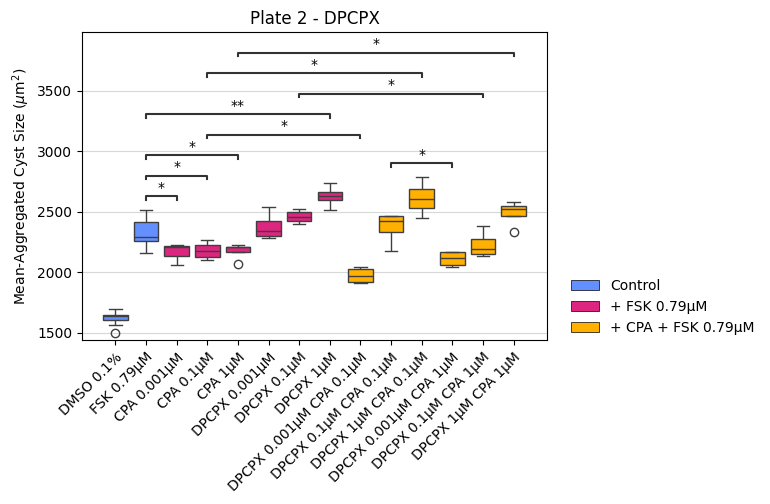

/tmp/ipykernel_2992906/2818115405.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cpd["Treatment 2 Sort Key"] = subset_cpd["Treatment 2"].apply(
/tmp/ipykernel_2992906/2818115405.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=10)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

FSK 0.79µM vs. CPA 0.001µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.848e-02 U_stat=2.200e+01
FSK 0.79µM vs. CPA 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.828e-02 U_stat=2.900e+01
Capadenoson 0.1µM CPA 0.1µM vs. Capadenoson 0.001µM CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=0.000e+00
FSK 0.79µM vs. CPA 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.828e-02 U_stat=2.900e+01
Capadenoson 0.001µM vs. Capadenoson 0.1µM CPA 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:2.857e-02 U_stat=1.600e+01
FSK 0.79µM vs. Capadenoson 0.1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.040e-03 U_stat=3.200e+01
FSK 0.79µM vs. Capadenoson 1µM: Mann-Whitney-Wilcoxon test two-sided, P_val:4.040e-03 U_stat=3.200e+01
CPA 0.1µM vs. Capadenoson 0.1µM CPA 0.1µM: Mann-Whitn

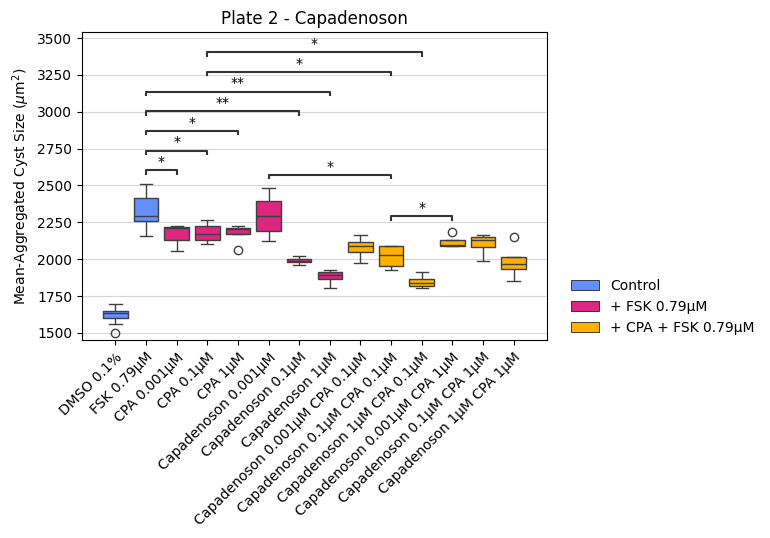

In [7]:
mycpds_treatment = [
    "DPCPX",
    "Capadenoson",
]
plot_single_plate(mycpds_treatment, 2, "CPA", 2.5, savefig=False)
plot_single_plate(mycpds_treatment, 2, "CPA", 0.79, savefig=False)

# With the curves and all? 

In [8]:
def make_treat_string(row):
    if row["treatment_type"] in ["solvent_ctrl", "stim_only"]:
        return row["Treatment"] + " " + str(row["Treatment concentration"]) + row["Treatment unit"]
    else:
        return row["Treatment"] + " " + str(row["Treatment concentration"]) + row["Treatment unit"]


def add_treatment_2(row):
    if pd.notna(row["Treatment_2"]):
        if row["treatment_type"] == "treatment" and row["Treatment"] == "DMSO":
            # In this case, we have like DMSO 0.1% + CPA 1µM
            return row["Treatment_2"] + " " + str(row["Treatment_2_concentration"]) + row["Treatment_2_unit"]
        elif row["Treatment_2"] == "DMSO":
            return (
                row["treat_string"]
                + " + "
                + row["Stimulant"]
                + " "
                + str(row["Stimulant dose"])
                + row["Stimulant unit"]
            )
        else:
            return (
                row["treat_string"]
                + " + "
                + row["Treatment_2"]
                + " "
                + str(row["Treatment_2_concentration"])
                + row["Treatment_2_unit"]
            )
    else:
        return row["treat_string"]


def change_control_row(row):
    if row["treatment_type"] == "solvent_ctrl":
        return "DMSO 0.1%"
    elif row["treatment_type"] == "stim_only":
        return f"FSK {row['Stimulant dose']}µM"
    else:
        return row["treat_string"]


def clean_treatment_string(text, single_treatment: bool = False):
    if single_treatment:
        return re.sub(r"\s\d\.\d+µM", "", text)
    else:
        return re.sub(r"([A-Za-z]+)\s\d\.\d+µM(?=.+)", r"\1", text)

In [9]:
def plot_with_curves(df, plate_id, toplot_compound, single_treatment: bool = False, plot_normalized=True):
    # Some variables...
    spheresize_col = "obj.Mean(area).um2.meas"
    # if plot_normalized:
    #     spheresize_col += "_norm" # TODO: add normalized plots
    rm_fsk_pattern = re.compile(r"\s\+\sFSK \d\.\d+µM")

    # prepare the data by cleaning the treatment strings as we want  them for the plot
    df = df.query(f"plate_id == {plate_id}").drop(columns=["Name", "QC_problems"])
    df = (
        df.replace({"uM": "µM", "pct": "%"})
        .rename(
            columns={
                "Treatment 2": "Treatment_2",
                "Treatment 2 concentration": "Treatment_2_concentration",
                "Treatment 2 unit": "Treatment_2_unit",
            }
        )
        .assign(
            treat_string=lambda x: x["Treatment"]
            + " "
            + x["Treatment concentration"].astype(str)
            + x["Treatment unit"]
        )
    )
    df["treat_string"] = df.apply(add_treatment_2, axis=1)
    df["treat_string"] = df.apply(change_control_row, axis=1)

    # Colors for the treatment groups
    colors = ["#648FFF", "#DC267F", "#FFB000"]
    rgb_colors = [mcolors.to_rgba(c) for c in colors]

    # Define subsets for the control groups
    unstimulated = df.query("treat_string == 'DMSO 0.1%'").assign(whatever=1)
    stimulated = df.query("treat_string == 'FSK 2.5µM'").assign(whatever=1)
    half_stimulated = df.query("treat_string == 'FSK 0.79µM'").assign(whatever=1)

    controls = [unstimulated, half_stimulated, stimulated]
    control_colors = ["silver", "rosybrown", "maroon"]

    fig, axs = plt.subplots(ncols=2, figsize=(6, 4), sharey=True, gridspec_kw={"width_ratios": [1, 5]})
    control_ax = axs[0]
    for control, color in zip(controls, control_colors):
        sns.boxplot(
            data=control,
            x="whatever",
            y=spheresize_col,
            hue="treat_string",
            ax=control_ax,
            palette=[mcolors.to_rgb(color)],
        )

    ax = axs[1]  # where the treatment groups will be plotted
    seaborn_graphic = sns.pointplot(
        data=(
            df.rename(columns={"Stimulant dose": "Stimulant_dose"})
            .query("treat_string.str.contains(@toplot_compound)")
            .query("Stimulant_dose == 2.5")
            .sort_values(["Treatment", "Treatment concentration"])
            .assign(logC=lambda x: np.log10(x["Treatment concentration"]))
            .assign(
                hue_string=lambda x: x["treat_string"].apply(
                    clean_treatment_string, single_treatment=single_treatment
                )
            )
            .assign(hue_string=lambda x: x["hue_string"].apply(lambda s: rm_fsk_pattern.sub("", s)))
        ),
        x="logC",
        y=spheresize_col,
        hue="hue_string",
        palette=rgb_colors,
        native_scale=True,
        ax=ax,
        zorder=10,
    )
    seaborn_graphic.legend().set_visible(False)

    ax = plt.gca()

    # make a dotted line for the median of each control group
    median_unstimulated = unstimulated[spheresize_col].median()
    median_stimulated = stimulated[spheresize_col].median()
    median_half_stimulated = half_stimulated[spheresize_col].median()
    ax.axhline(median_unstimulated, color="silver", linestyle="--")  # label="median(DMSO 0.1%)")
    ax.axhline(median_half_stimulated, color="rosybrown", linestyle="--")  # label="median(FSK 0.79µM)")
    ax.axhline(median_stimulated, color="maroon", linestyle="--")  # label="median(FSK 2.5µM)")

    # make the legends with all the labels
    handles1, labels1 = control_ax.get_legend_handles_labels()
    handles2, labels2 = ax.get_legend_handles_labels()  # This will now include the horizontal lines
    all_handles = handles2 + handles1
    all_labels = labels2 + labels1
    if control_ax.get_legend() is not None:
        control_ax.get_legend().remove()
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.legend(
        all_handles, all_labels, bbox_to_anchor=(1.04, 0), loc="lower left", borderaxespad=0, frameon=False
    )

    ax.set_xlabel(r"log$_{10}$" + f"(Concentration) {toplot_compound} [µM]")
    ax.set_ylabel(r"Mean-Aggregated Cyst Size ($\mu$m$^2$)")
    plt.xticks([-3.0, -1.0, 0.0])
    ax.set_title(f"Plate {plate_id} - {toplot_compound}")
    ax.spines[["right", "top"]].set_visible(False)

    control_ax.legend().set_visible(False)
    control_ax.set_ylabel(r"Mean-Aggregated Cyst Size ($\mu$m$^2$)")
    control_ax.xaxis.set_ticklabels([])
    control_ax.set_xlabel("Control Groups")
    control_ax.spines[["right", "top"]].set_visible(False)
    # for axis in [ax, control_ax]:
    #     axis.grid(axis="y", alpha=0.25)
    #     axis.set_axisbelow(True)
    return seaborn_graphic
    # ax.legend(bbox_to_anchor=(1.04, 0), loc="lower left", borderaxespad=0, frameon=False)

/tmp/ipykernel_2992906/100303549.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"uM": "µM", "pct": "%"})
/tmp/ipykernel_2992906/100303549.py:54: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  seaborn_graphic = sns.pointplot(
/tmp/ipykernel_2992906/100303549.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"uM": "µM", "pct": "%"})
/tmp/ipykernel_2992906/100303549.py:54: UserWarning: The palette list has more values (3) than needed (1), which may not 

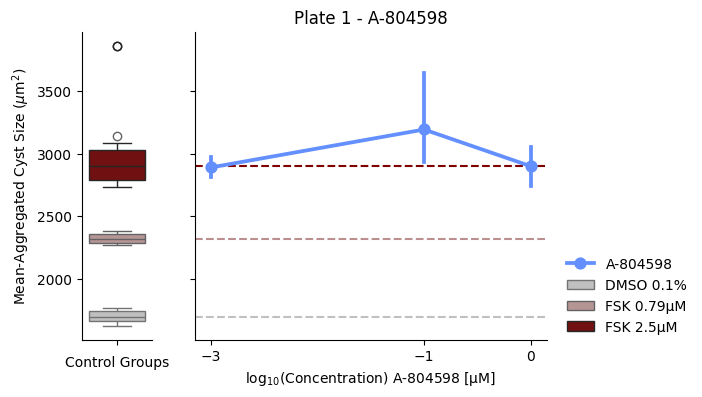

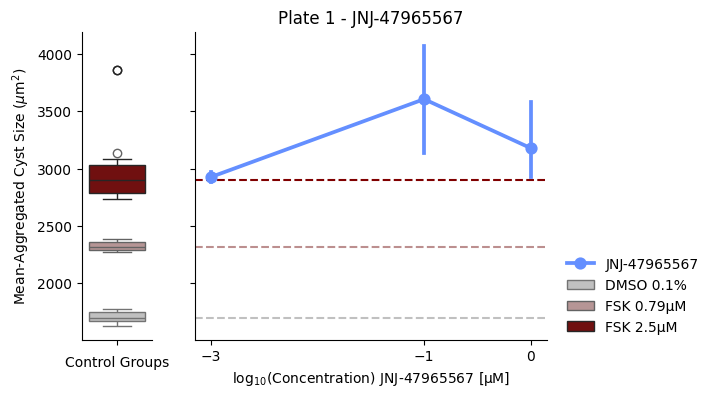

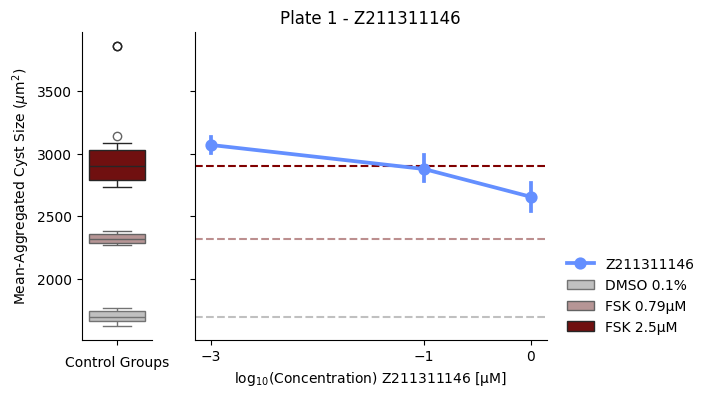

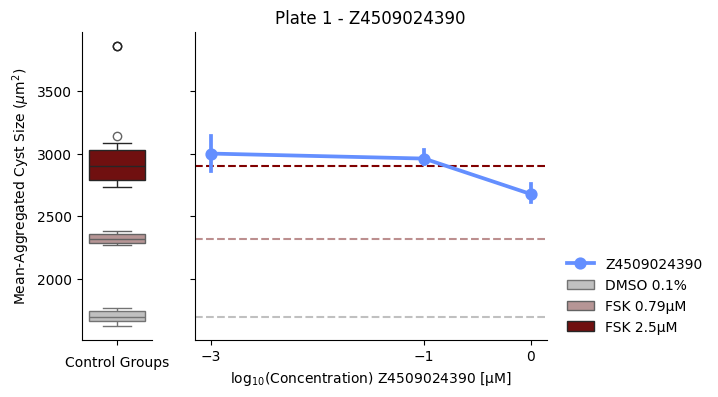

In [10]:
_ = plot_with_curves(df_old, 1, "A-804598", single_treatment=True)
_ = plot_with_curves(df_old, 1, "JNJ-47965567", single_treatment=True)
_ = plot_with_curves(df_old, 1, "Z211311146", single_treatment=True)
_ = plot_with_curves(df_old, 1, "Z4509024390", single_treatment=True)

<Axes: title={'center': 'Plate 2 - DPCPX'}, xlabel='log$_{10}$(Concentration) DPCPX [µM]', ylabel='Mean-Aggregated Cyst Size ($\\mu$m$^2$)'>

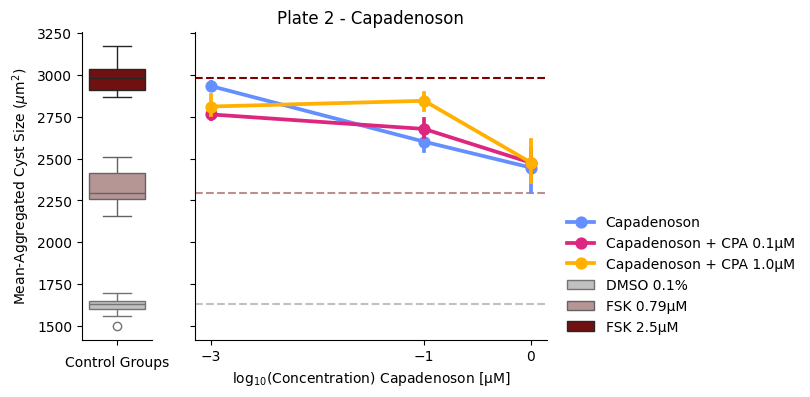

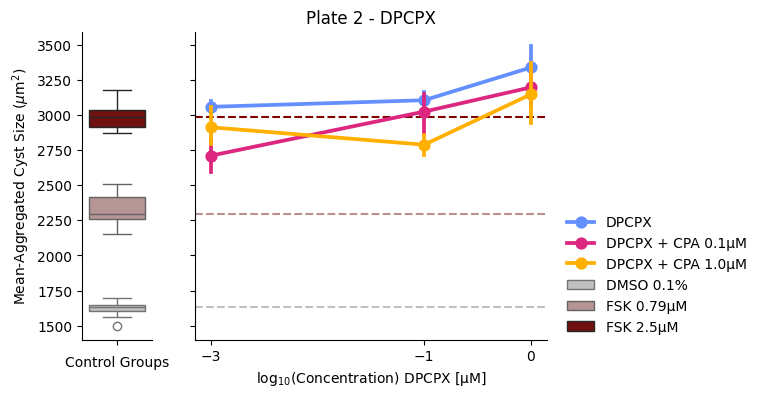

In [11]:
plot_with_curves(df_old, 2, "Capadenoson")
plot_with_curves(df_old, 2, "DPCPX")

<Axes: title={'center': 'Plate 3 - Finerenone'}, xlabel='log$_{10}$(Concentration) Finerenone [µM]', ylabel='Mean-Aggregated Cyst Size ($\\mu$m$^2$)'>

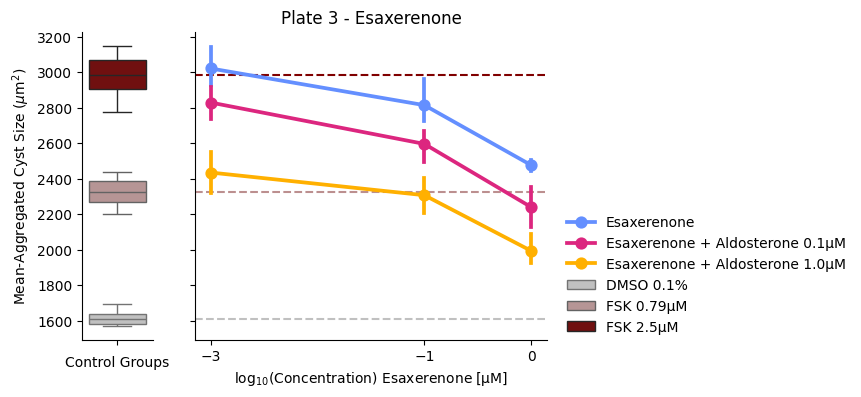

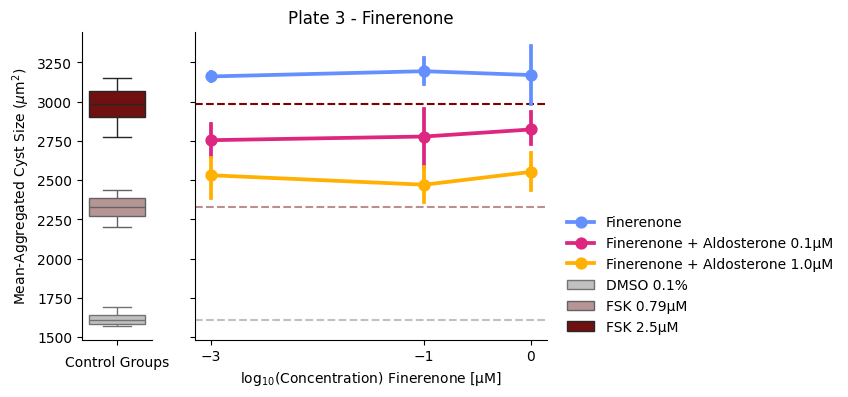

In [12]:
plot_with_curves(df_old, 3, "Esaxerenone")
plot_with_curves(df_old, 3, "Finerenone")